In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [8]:
import os
print(os.getcwd())


/content


In [9]:
print(os.listdir("/"))

['bin', 'boot', 'usr', 'srv', 'proc', 'run', 'lib32', 'etc', 'lib64', 'tmp', 'var', 'media', 'libx32', 'opt', 'home', 'lib', 'mnt', 'dev', 'sbin', 'sys', 'root', 'kaggle', 'archive.zip', 'netflix_titles.csv', '.dockerenv', 'tools', 'datalab', 'content', 'python-apt', 'python-apt.tar.xz']


In [10]:
df = pd.read_csv("/netflix_titles.csv")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [12]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [13]:
df['country'].fillna('Unknown', inplace=True)

df['rating'].fillna('Unknown', inplace=True)

df.dropna(subset=['date_added'], inplace=True)

/tmp/ipykernel_4028/2125426396.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown', inplace=True)
/tmp/ipykernel_4028/2125426396.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

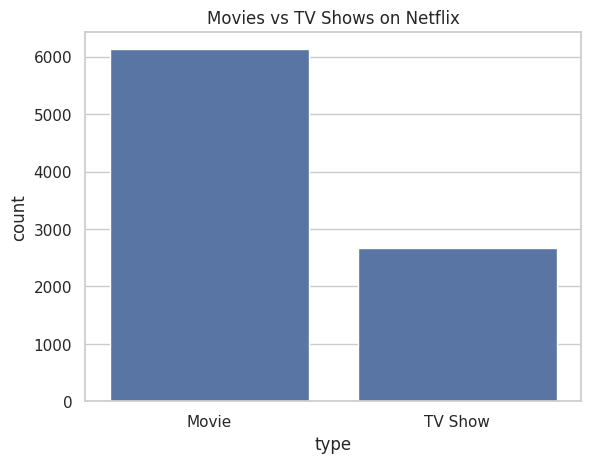

In [14]:
sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows on Netflix")

plt.show()

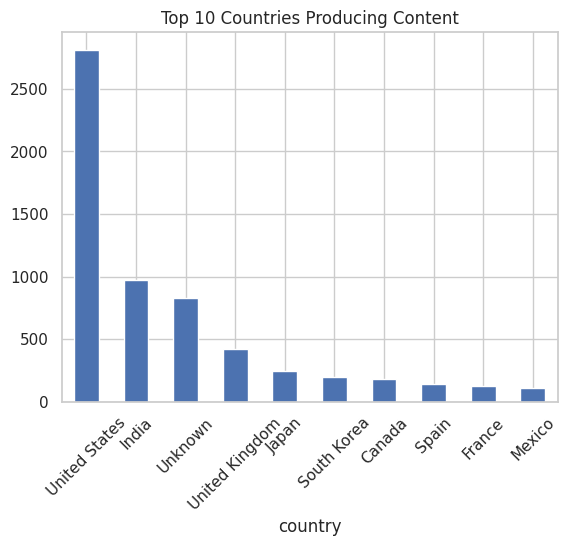

In [15]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title("Top 10 Countries Producing Content")

plt.xticks(rotation=45)

plt.show()

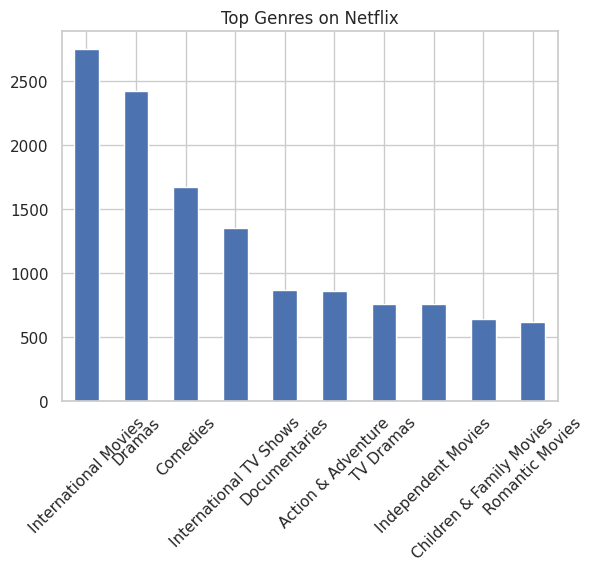

In [16]:
genres = df['listed_in'].str.split(', ', expand=True).stack()

top_genres = genres.value_counts().head(10)

top_genres.plot(kind='bar')

plt.title("Top Genres on Netflix")

plt.xticks(rotation=45)

plt.show()

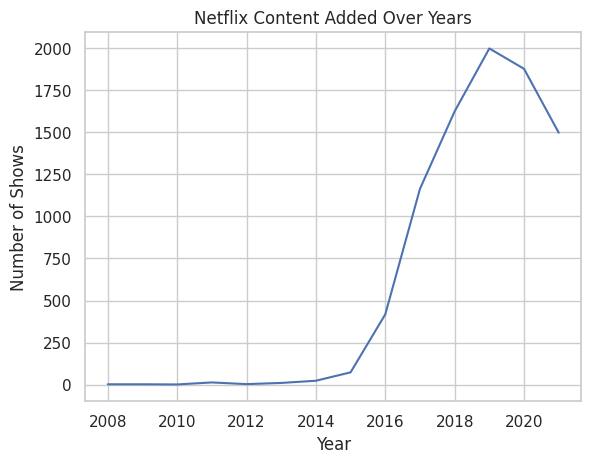

In [19]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index().plot()

plt.title("Netflix Content Added Over Years")

plt.xlabel("Year")

plt.ylabel("Number of Shows")

plt.show()

# Insights

- Movies are more common than TV Shows on Netflix.
- USA produces the highest amount of content.
- Drama and International genres are most popular.
- Netflix content grew rapidly after 2015.
